# From Pilot to Payoff - 06: Q5 - Workforce Outcomes and Bayesian Inference

Q5: Is advanced adoption associated with workforce outcomes and lower implementation risk?


### Q5 - Workforce Outcomes and Bayesian Inference

This section evaluates whether advanced adoption is associated with workforce reskilling, net job creation, and lower failure rates. It also includes a Bayesian Beta-Binomial component, matching the proposal and Session 8 Bayesian methods.


## Setup and data preparation

Re-runs the shared imports, data loading, feature engineering, and standardisation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

from statsmodels.formula.api import ols

import matplotlib.pyplot as plt
import seaborn as sns

# Folder for saving generated figures.
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
industry_summary = pd.read_csv('ai_industry_summary.csv')

print('Dataset shapes')
print(f'company adoption: {company.shape[0]:,} rows x {company.shape[1]:,} columns')
print(f'country index:    {country_index.shape[0]:,} rows x {country_index.shape[1]:,} columns')
print(f'industry summary: {industry_summary.shape[0]:,} rows x {industry_summary.shape[1]:,} columns')

company.head(3)


Dataset shapes
company adoption: 150,000 rows x 43 columns
country index:    30 rows x 8 columns
industry summary: 9 rows x 8 columns


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering and merge.
quarter_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
company = company.copy()
company['quarter_num'] = company['quarter'].map(quarter_map)
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)
company['net_jobs_created'] = company['jobs_created'] - company['jobs_displaced']
company['net_jobs_per_100_employees'] = company['net_jobs_created'] / company['num_employees'] * 100
company['reskilling_rate_per_100_employees'] = company['reskilled_employees'] / company['num_employees'] * 100

# Log transform for the skewed investment variable.
# 780 firms (0.52%) report zero AI investment; np.log1p collapses these to 0, far below the
# positive mass (median log ~10.7), creating an artificial left-skewed spike (skew -2.8) that
# distorts the standardised predictor feeding the Q3 logistic model. Instead, log the positive
# amounts (near-symmetric, skew -0.43) and set the rare zeros to the median log, so they sit at
# the centre rather than forming a distorting tail.
_pos_investment = company['ai_investment_per_employee'] > 0
_log_investment = np.log(company['ai_investment_per_employee'].where(_pos_investment))
company['log_ai_investment_per_employee'] = _log_investment.fillna(_log_investment.median())

country_model = country_index.drop(columns=['region'])
country_model['log_gdp_per_capita'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_ai_patent_filings_2024'] = np.log1p(country_model['ai_patent_filings_2024'])

df = company.merge(country_model, on='country', how='left')

# Latest observation per company for robustness checks.
latest_obs = (df.sort_values(['company_id', 'survey_year', 'quarter_num'])
                .groupby('company_id', as_index=False)
                .tail(1)
                .reset_index(drop=True))

# Digital maturity tertiles for interaction models.
df['digital_maturity_tertile'] = pd.qcut(
    df['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)
latest_obs['digital_maturity_tertile'] = pd.qcut(
    latest_obs['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)

merge_check = df[['country', 'digital_maturity_index']].isna().mean().rename('missing_rate')
print(f'Merged modelling data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Latest-company robustness data: {latest_obs.shape[0]:,} rows')
print('\nCountry-index missing check:')
print(merge_check)


Merged modelling data: 150,000 rows x 58 columns
Latest-company robustness data: 10,000 rows

Country-index missing check:
country                   0.0
digital_maturity_index    0.0
Name: missing_rate, dtype: float64


In [4]:
# Standardise numeric predictors used in regression models.
standardise_cols = [
    'ai_training_hours', 'num_ai_tools_used', 'ai_projects_active', 'years_using_ai',
    'ai_budget_percentage', 'log_ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score'
]

for col in standardise_cols:
    mean = df[col].mean()
    std = df[col].std(ddof=0)
    df[f'z_{col}'] = (df[col] - mean) / std
    latest_obs[f'z_{col}'] = (latest_obs[col] - mean) / std

print('Created z-score variables for regression comparability.')


Created z-score variables for regression comparability.


In [5]:
stage_order = ['none', 'pilot', 'partial', 'full']

In [6]:
# Control terms reused from the Q4 module so this notebook is self-contained.
ols_control_terms = 'C(country) + C(industry) + C(company_size) + C(survey_year) + C(quarter)'


In [7]:
# Group comparison of each workforce outcome by adoption maturity.
# Kruskal-Wallis across the four stages, and Mann-Whitney U (advanced vs non-advanced).
# H0: no difference in distribution between groups.  H1: a difference exists.  alpha = 0.05.
workforce_outcomes = {
    'net_jobs_per_100_employees': 'Net jobs per 100 employees',
    'reskilling_rate_per_100_employees': 'Reskilled employees per 100 employees',
    'ai_failure_rate': 'AI failure rate',
    'time_saved_per_week': 'Time saved per week',
    'task_automation_rate': 'Task automation rate (%)'
}

workforce_rows = []
for col, label in workforce_outcomes.items():
    stage_groups = [df.loc[df['ai_adoption_stage'] == stage, col].dropna() for stage in stage_order]
    h_stat, kw_p = stats.kruskal(*stage_groups)
    adv = df.loc[df['advanced_adoption'] == 1, col]
    nonadv = df.loc[df['advanced_adoption'] == 0, col]
    u_stat, mw_p = stats.mannwhitneyu(adv, nonadv, alternative='two-sided')
    workforce_rows.append({
        'outcome': label,
        'advanced_mean': adv.mean(),
        'non_advanced_mean': nonadv.mean(),
        'mean_difference': adv.mean() - nonadv.mean(),
        'kruskal_p_value': kw_p,
        'mann_whitney_p_value': mw_p
    })

workforce_tests = pd.DataFrame(workforce_rows)
workforce_tests


,outcome,advanced_mean,non_advanced_mean,mean_difference,kruskal_p_value,mann_whitney_p_value
0,Net jobs per 100 employees,0.334193,-0.177124,0.511317,0.0,0.0
1,Reskilled employees per 100 employees,8.057654,4.741435,3.316219,0.0,0.0
2,AI failure rate,21.282286,30.975268,-9.692982,0.0,0.0
3,Time saved per week,7.651907,4.664419,2.987489,0.0,0.0
4,Task automation rate (%),24.593363,14.167657,10.425706,0.0,0.0


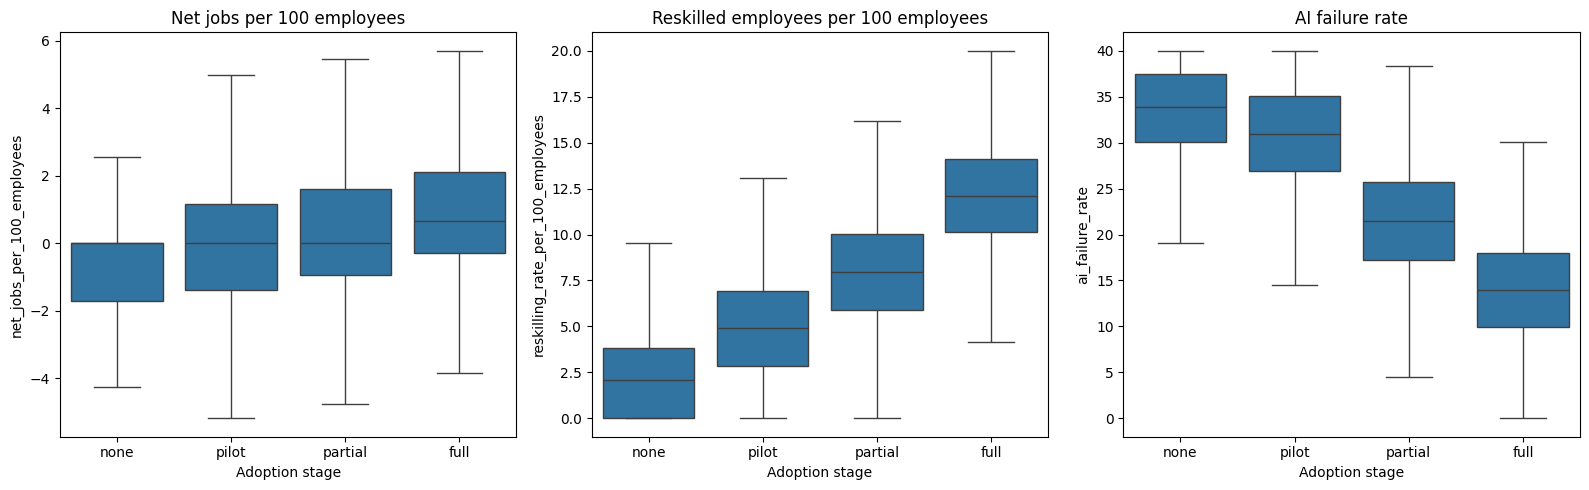

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_cols = ['net_jobs_per_100_employees', 'reskilling_rate_per_100_employees', 'ai_failure_rate']
for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x='ai_adoption_stage', y=col, order=stage_order, showfliers=False, ax=ax)
    ax.set_title(workforce_outcomes[col])
    ax.set_xlabel('Adoption stage')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_07_workforce_outcomes.png', bbox_inches='tight')
plt.show()


In [9]:
workforce_ols_rows = []
for outcome, label in workforce_outcomes.items():
    m0 = ols(f'{outcome} ~ {ols_control_terms}', data=df).fit()
    m1 = ols(f'{outcome} ~ advanced_adoption + {ols_control_terms}', data=df).fit()
    workforce_ols_rows.append({
        'outcome': label,
        'advanced_beta': m1.params.get('advanced_adoption', np.nan),
        'p_value': m1.pvalues.get('advanced_adoption', np.nan),
        'adj_R2_controls': m0.rsquared_adj,
        'adj_R2_plus_advanced': m1.rsquared_adj,
        'delta_adj_R2': m1.rsquared_adj - m0.rsquared_adj
    })

workforce_ols_summary = pd.DataFrame(workforce_ols_rows)
workforce_ols_summary


,outcome,advanced_beta,p_value,adj_R2_controls,adj_R2_plus_advanced,delta_adj_R2
0,Net jobs per 100 employees,0.440476,0.0,0.026666,0.036930,0.010264
1,Reskilled employees per 100 employees,3.070670,0.0,0.068087,0.245887,0.177800
2,AI failure rate,-9.216702,0.0,0.080043,0.404267,0.324224
3,Time saved per week,2.845011,0.0,0.059102,0.268993,0.209891
4,Task automation rate (%),10.064221,0.0,0.069821,0.343593,0.273772


#### Bayesian cross-check: which firm sizes are furthest along?

As a complementary Bayesian view (Session 8), we estimate the *probability* of advanced adoption for each company-size group using a Beta-Binomial model, with 95% credible intervals. This is not a workforce outcome itself; it is a side analysis that shows which firm groups are most advanced in adoption and quantifies the uncertainty around those rates.

In [10]:
# Bayesian Beta-Binomial model on latest company observation to avoid repeated firm-quarter counting.
size_counts = (latest_obs.groupby('company_size')['advanced_adoption']
                 .agg(x='sum', n='count')
                 .reindex(['Startup', 'SME', 'Enterprise'])
                 .reset_index())

alpha_prior, beta_prior = 1, 1
posterior_rows = []
posterior_dists = {}
for _, row in size_counts.iterrows():
    group = row['company_size']
    x = int(row['x'])
    n_group = int(row['n'])
    a_post = alpha_prior + x
    b_post = beta_prior + n_group - x
    dist = stats.beta(a_post, b_post)
    posterior_dists[group] = dist
    ci = dist.ppf([0.025, 0.975])
    posterior_rows.append({
        'company_size': group,
        'successes_x': x,
        'n': n_group,
        'posterior_mean': a_post / (a_post + b_post),
        'ci_2_5': ci[0],
        'ci_97_5': ci[1]
    })

posterior_summary = pd.DataFrame(posterior_rows)
posterior_summary


,company_size,successes_x,n,posterior_mean,ci_2_5,ci_97_5
0,Startup,2292,3780,0.606293,0.590672,0.621808
1,SME,2551,4258,0.599061,0.584303,0.613731
2,Enterprise,1543,1962,0.786151,0.767749,0.804000


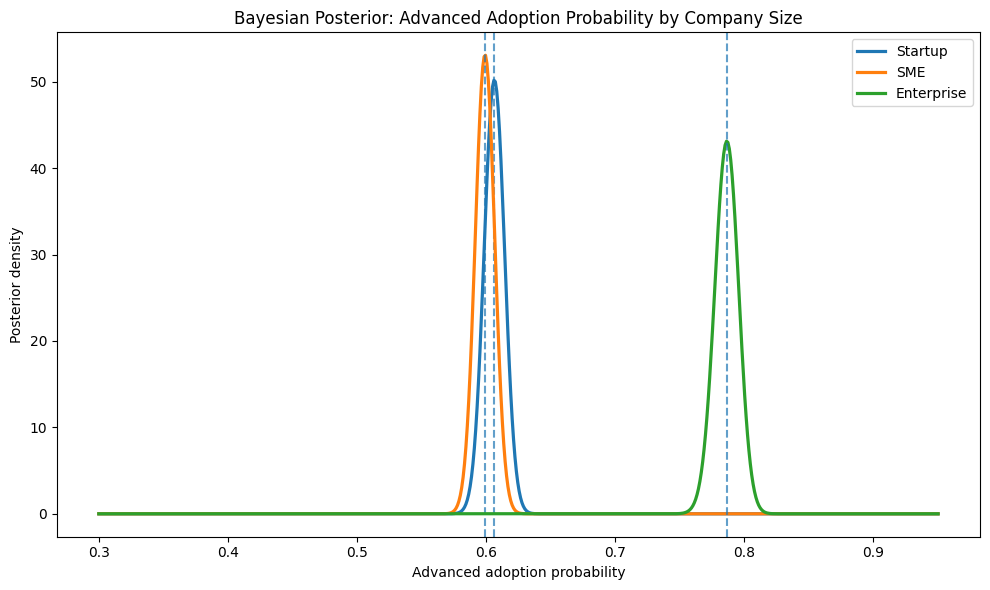

In [11]:
# Visualise the posterior distributions of advanced-adoption probability by company size.
xs = np.linspace(0.3, 0.95, 600)
fig, ax = plt.subplots(figsize=(10, 6))
for group, dist in posterior_dists.items():
    ax.plot(xs, dist.pdf(xs), lw=2.3, label=group)
    ax.axvline(dist.mean(), linestyle='--', alpha=0.7)
ax.set_title('Bayesian Posterior: Advanced Adoption Probability by Company Size')
ax.set_xlabel('Advanced adoption probability')
ax.set_ylabel('Posterior density')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_08_bayesian_posteriors.png', bbox_inches='tight')
plt.show()


In [12]:
# Prior sensitivity: compare Beta(1,1) and Beta(2,2).
sensitivity_rows = []
for _, row in size_counts.iterrows():
    group = row['company_size']
    x = int(row['x'])
    n_group = int(row['n'])
    for prior_label, (a0, b0) in {'Beta(1,1)': (1, 1), 'Beta(2,2)': (2, 2)}.items():
        dist = stats.beta(a0 + x, b0 + n_group - x)
        ci = dist.ppf([0.025, 0.975])
        sensitivity_rows.append({
            'company_size': group,
            'prior': prior_label,
            'posterior_mean': dist.mean(),
            'ci_2_5': ci[0],
            'ci_97_5': ci[1]
        })

prior_sensitivity = pd.DataFrame(sensitivity_rows)
prior_sensitivity


,company_size,prior,posterior_mean,ci_2_5,ci_97_5
0,Startup,"Beta(1,1)",0.606293,0.590672,0.621808
1,Startup,"Beta(2,2)",0.606237,0.590619,0.621748
2,SME,"Beta(1,1)",0.599061,0.584303,0.613731
3,SME,"Beta(2,2)",0.599015,0.584259,0.613682
4,Enterprise,"Beta(1,1)",0.786151,0.767749,0.804000
5,Enterprise,"Beta(2,2)",0.785860,0.767459,0.803709


**Q5 interpretation.** Advanced adoption is associated with more reskilling (delta adj R2 ~ 0.18), substantially lower AI failure rates (delta adj R2 ~ 0.32), and more time saved and task automation. The **net-job-creation** effect, by contrast, is statistically detectable but practically tiny: about 0.5 net jobs per 100 employees (delta adj R2 ~ 0.01), so it should not be presented as a headline benefit.

The Bayesian Beta-Binomial estimates use the latest observation per company (so each firm is counted once) and are robust to the prior (Beta(1,1) vs Beta(2,2) give nearly identical results). They show that **enterprises** adopt at markedly higher rates (posterior mean ~ 79%) than SMEs or startups: the enterprise credible interval does not overlap the others, while the SME and startup intervals overlap, so those two groups are similar. These latest-company rates (~60-79%) are higher than the pooled full-panel rates in Q1 (~49-71%), which is expected because advanced adoption rose over 2023-2026, so the most recent observation per firm reflects current rather than time-averaged adoption.
